In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# for dirname, _, filenames in os.walk("D:\HCMUT\STUDY\252\p4aids\btl\ieee-fraud-detection"):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [ ]:
train_identity = pd.read_csv("Dataset/train_identity.csv")
train_transaction = pd.read_csv("Dataset/train_transaction.csv")

print(f"train_identity.shape= {train_identity.shape}")
print(f"train_transaction.shape= {train_transaction.shape}")

train_identity.shape= (144233, 41)
train_transaction.shape= (590540, 394)


In [4]:
train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print("Merged Train:", train.shape)


Merged Train: (590540, 434)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

dist_cols = ['dist1', 'dist2']
c_cols = [f'C{i}' for i in range(1, 15)]
d_cols = [f'D{i}' for i in range(1, 16)]

In [6]:
def get_descriptive_stats(df, cols):
    subset = df[cols]
    desc = subset.describe().T
    missing = subset.isnull().mean() * 100
    desc['missing_pct'] = missing

    unique_counts = subset.nunique()
    desc['unique_count'] = unique_counts

    print(f'THỐNG KÊ MÔ TẢ')
    display(desc)
    return desc

def plot_group_analysis(df, group_name, cols):
    print(f'\n VISUALIZING GROUP: {group_name} ')

    # 1. Histograms with Fraud Rate
    n_cols = 3
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.histplot(df[col].dropna(), kde=False, ax=ax, bins=30, color='skyblue')
        ax.set_title(f'Dist & Fraud Rate of {col}')

        ax2 = ax.twinx()
        if df[col].nunique() > 20:
            temp_df = df[[col, 'isFraud']].dropna()
            temp_df['bin'] = pd.cut(temp_df[col], bins=30)
            fraud_rate = temp_df.groupby('bin')['isFraud'].mean()
            bin_centers = fraud_rate.index.map(lambda x: x.mid)
            ax2.plot(bin_centers, fraud_rate.values, color='red', linewidth=2)
        else:
            fraud_rate = df.groupby(col)['isFraud'].mean()
            ax2.plot(fraud_rate.index, fraud_rate.values, color='red', linewidth=2)

        ax2.set_ylabel('Fraud Rate', color='red')
        ax2.set_ylim(0, None)

    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    # 2. Correlation Matrix
    print(f'\n Correlation Matrix')
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.show()

In [7]:
# # Chỉ in thống kê mô tả cho nhóm biến V (không vẽ biểu đồ vì quá nhiều biến)
# if 'v_keep' in locals():
#     v_stats = get_descriptive_stats(train, v_keep)
# else:
#     print('Biến v_keep chưa được định nghĩa. Vui lòng chạy các cell xử lý biến V ở trên.')

# Distance features



THỐNG KÊ MÔ TẢ


,count,mean,std,min,25%,50%,75%,max,missing_pct,unique_count
dist1,238269.0,118.502180,371.872026,0.0,3.0,8.0,24.0,10286.0,59.652352,2651
dist2,37627.0,231.855423,529.053494,0.0,7.0,37.0,206.0,11623.0,93.628374,1751



 VISUALIZING GROUP: Dist1-2 


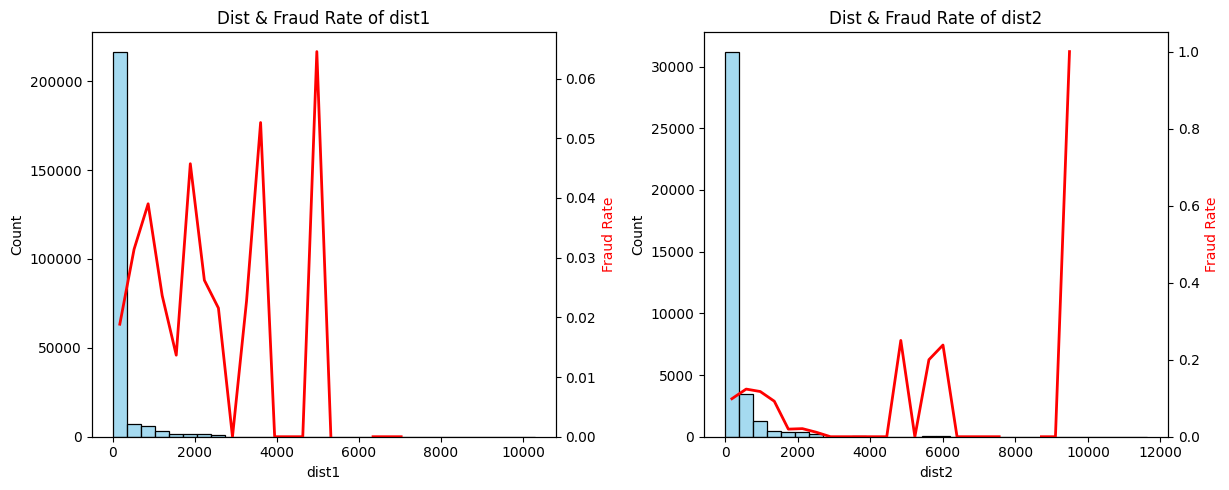


 Correlation Matrix


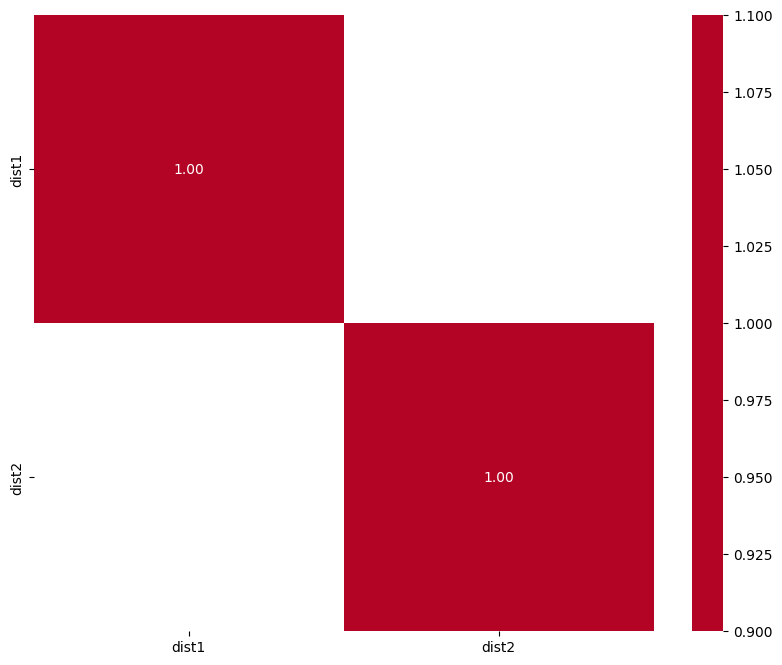

In [8]:
cols = [c for c in dist_cols if c in train.columns]
get_descriptive_stats(train, cols)
plot_group_analysis(train, 'Dist1-2', cols)

# C features

THỐNG KÊ MÔ TẢ


,count,mean,std,min,25%,50%,75%,max,missing_pct,unique_count
C1,590540.0,14.092458,133.569018,0.0,1.0,1.0,3.0,4685.0,0.0,1657
C2,590540.0,15.269734,154.668899,0.0,1.0,1.0,3.0,5691.0,0.0,1216
C3,590540.0,0.005644,0.150536,0.0,0.0,0.0,0.0,26.0,0.0,27
C4,590540.0,4.092185,68.848459,0.0,0.0,0.0,0.0,2253.0,0.0,1260
C5,590540.0,5.571526,25.786976,0.0,0.0,0.0,1.0,349.0,0.0,319
C6,590540.0,9.071082,71.508467,0.0,1.0,1.0,2.0,2253.0,0.0,1328
C7,590540.0,2.848478,61.727304,0.0,0.0,0.0,0.0,2255.0,0.0,1103
C8,590540.0,5.144574,95.378574,0.0,0.0,0.0,0.0,3331.0,0.0,1253
C9,590540.0,4.480240,16.674897,0.0,0.0,1.0,2.0,210.0,0.0,205
C10,590540.0,5.240343,95.581443,0.0,0.0,0.0,0.0,3257.0,0.0,1231



 VISUALIZING GROUP: C1-C14 


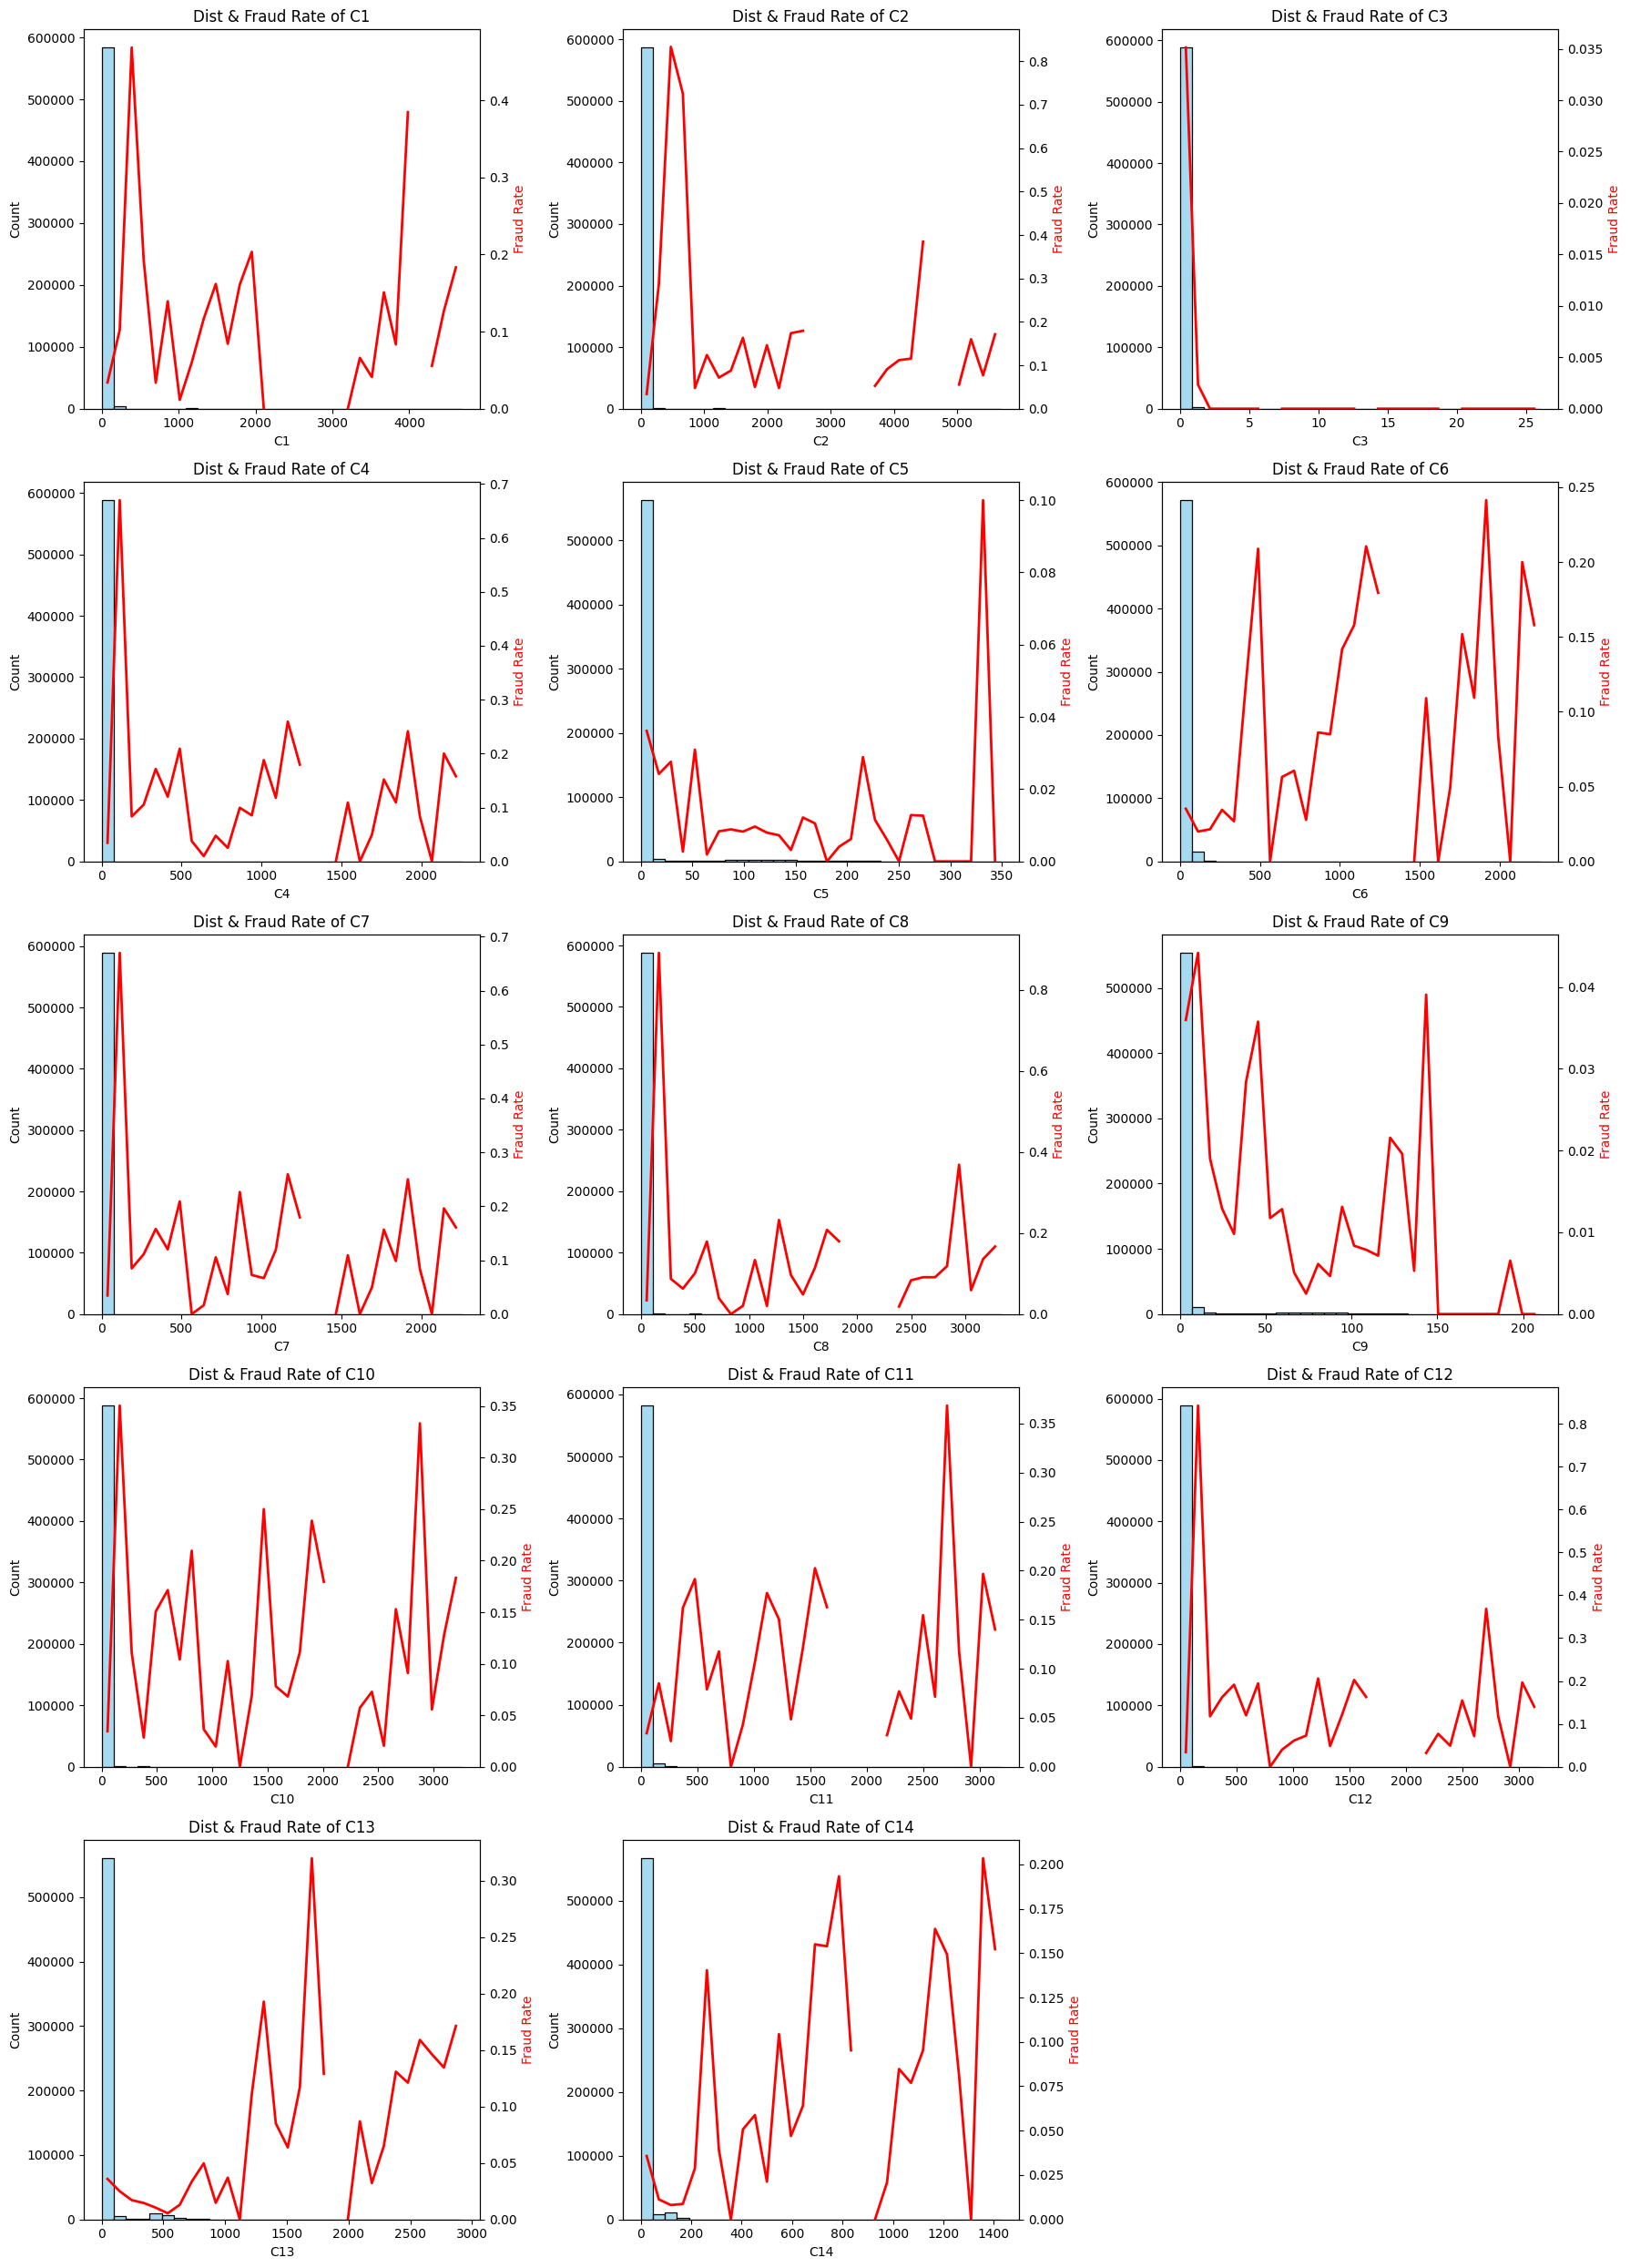


 Correlation Matrix


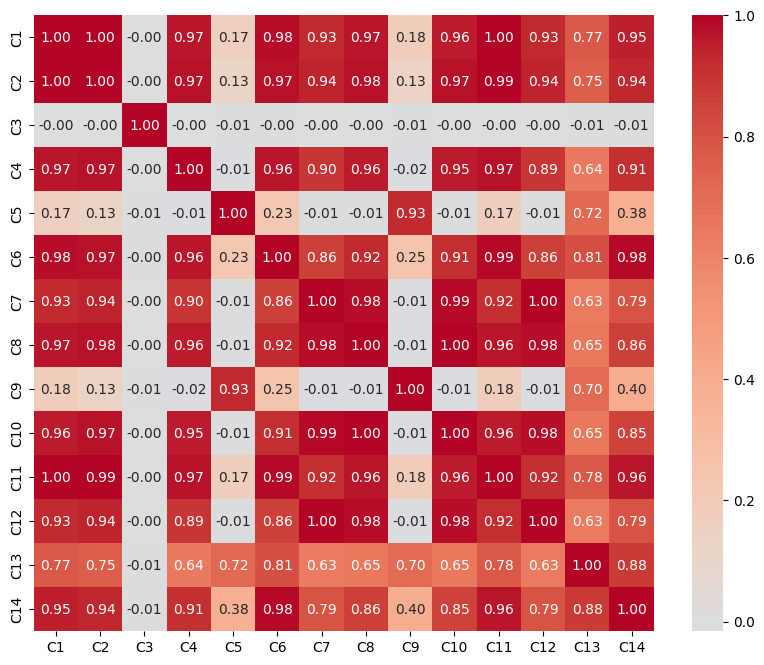

In [9]:
cols = [c for c in c_cols if c in train.columns]
get_descriptive_stats(train, cols)
plot_group_analysis(train, 'C1-C14', cols)

# D Features

THỐNG KÊ MÔ TẢ


,count,mean,std,min,25%,50%,75%,max,missing_pct,unique_count
D1,589271.0,94.347568,157.660387,0.0,0.000000,3.000000,122.000000,640.000000,0.214888,641
D2,309743.0,169.563231,177.315865,0.0,26.000000,97.000000,276.000000,640.000000,47.549192,641
D3,327662.0,28.343348,62.384721,0.0,1.000000,8.000000,27.000000,819.000000,44.514851,649
D4,421618.0,140.002441,191.096774,-122.0,0.000000,26.000000,253.000000,869.000000,28.604667,808
D5,280699.0,42.335965,89.000144,0.0,1.000000,10.000000,32.000000,819.000000,52.467403,688
D6,73187.0,69.805717,143.669253,-83.0,0.000000,0.000000,40.000000,873.000000,87.606767,829
D7,38917.0,41.638950,99.743264,0.0,0.000000,0.000000,17.000000,843.000000,93.409930,597
D8,74926.0,146.058108,231.663840,0.0,0.958333,37.875000,187.958328,1707.791626,87.312290,12353
D9,74926.0,0.561057,0.316880,0.0,0.208333,0.666666,0.833333,0.958333,87.312290,24
D10,514518.0,123.982137,182.615225,0.0,0.000000,15.000000,197.000000,876.000000,12.873302,818



 VISUALIZING GROUP: D1-D15 


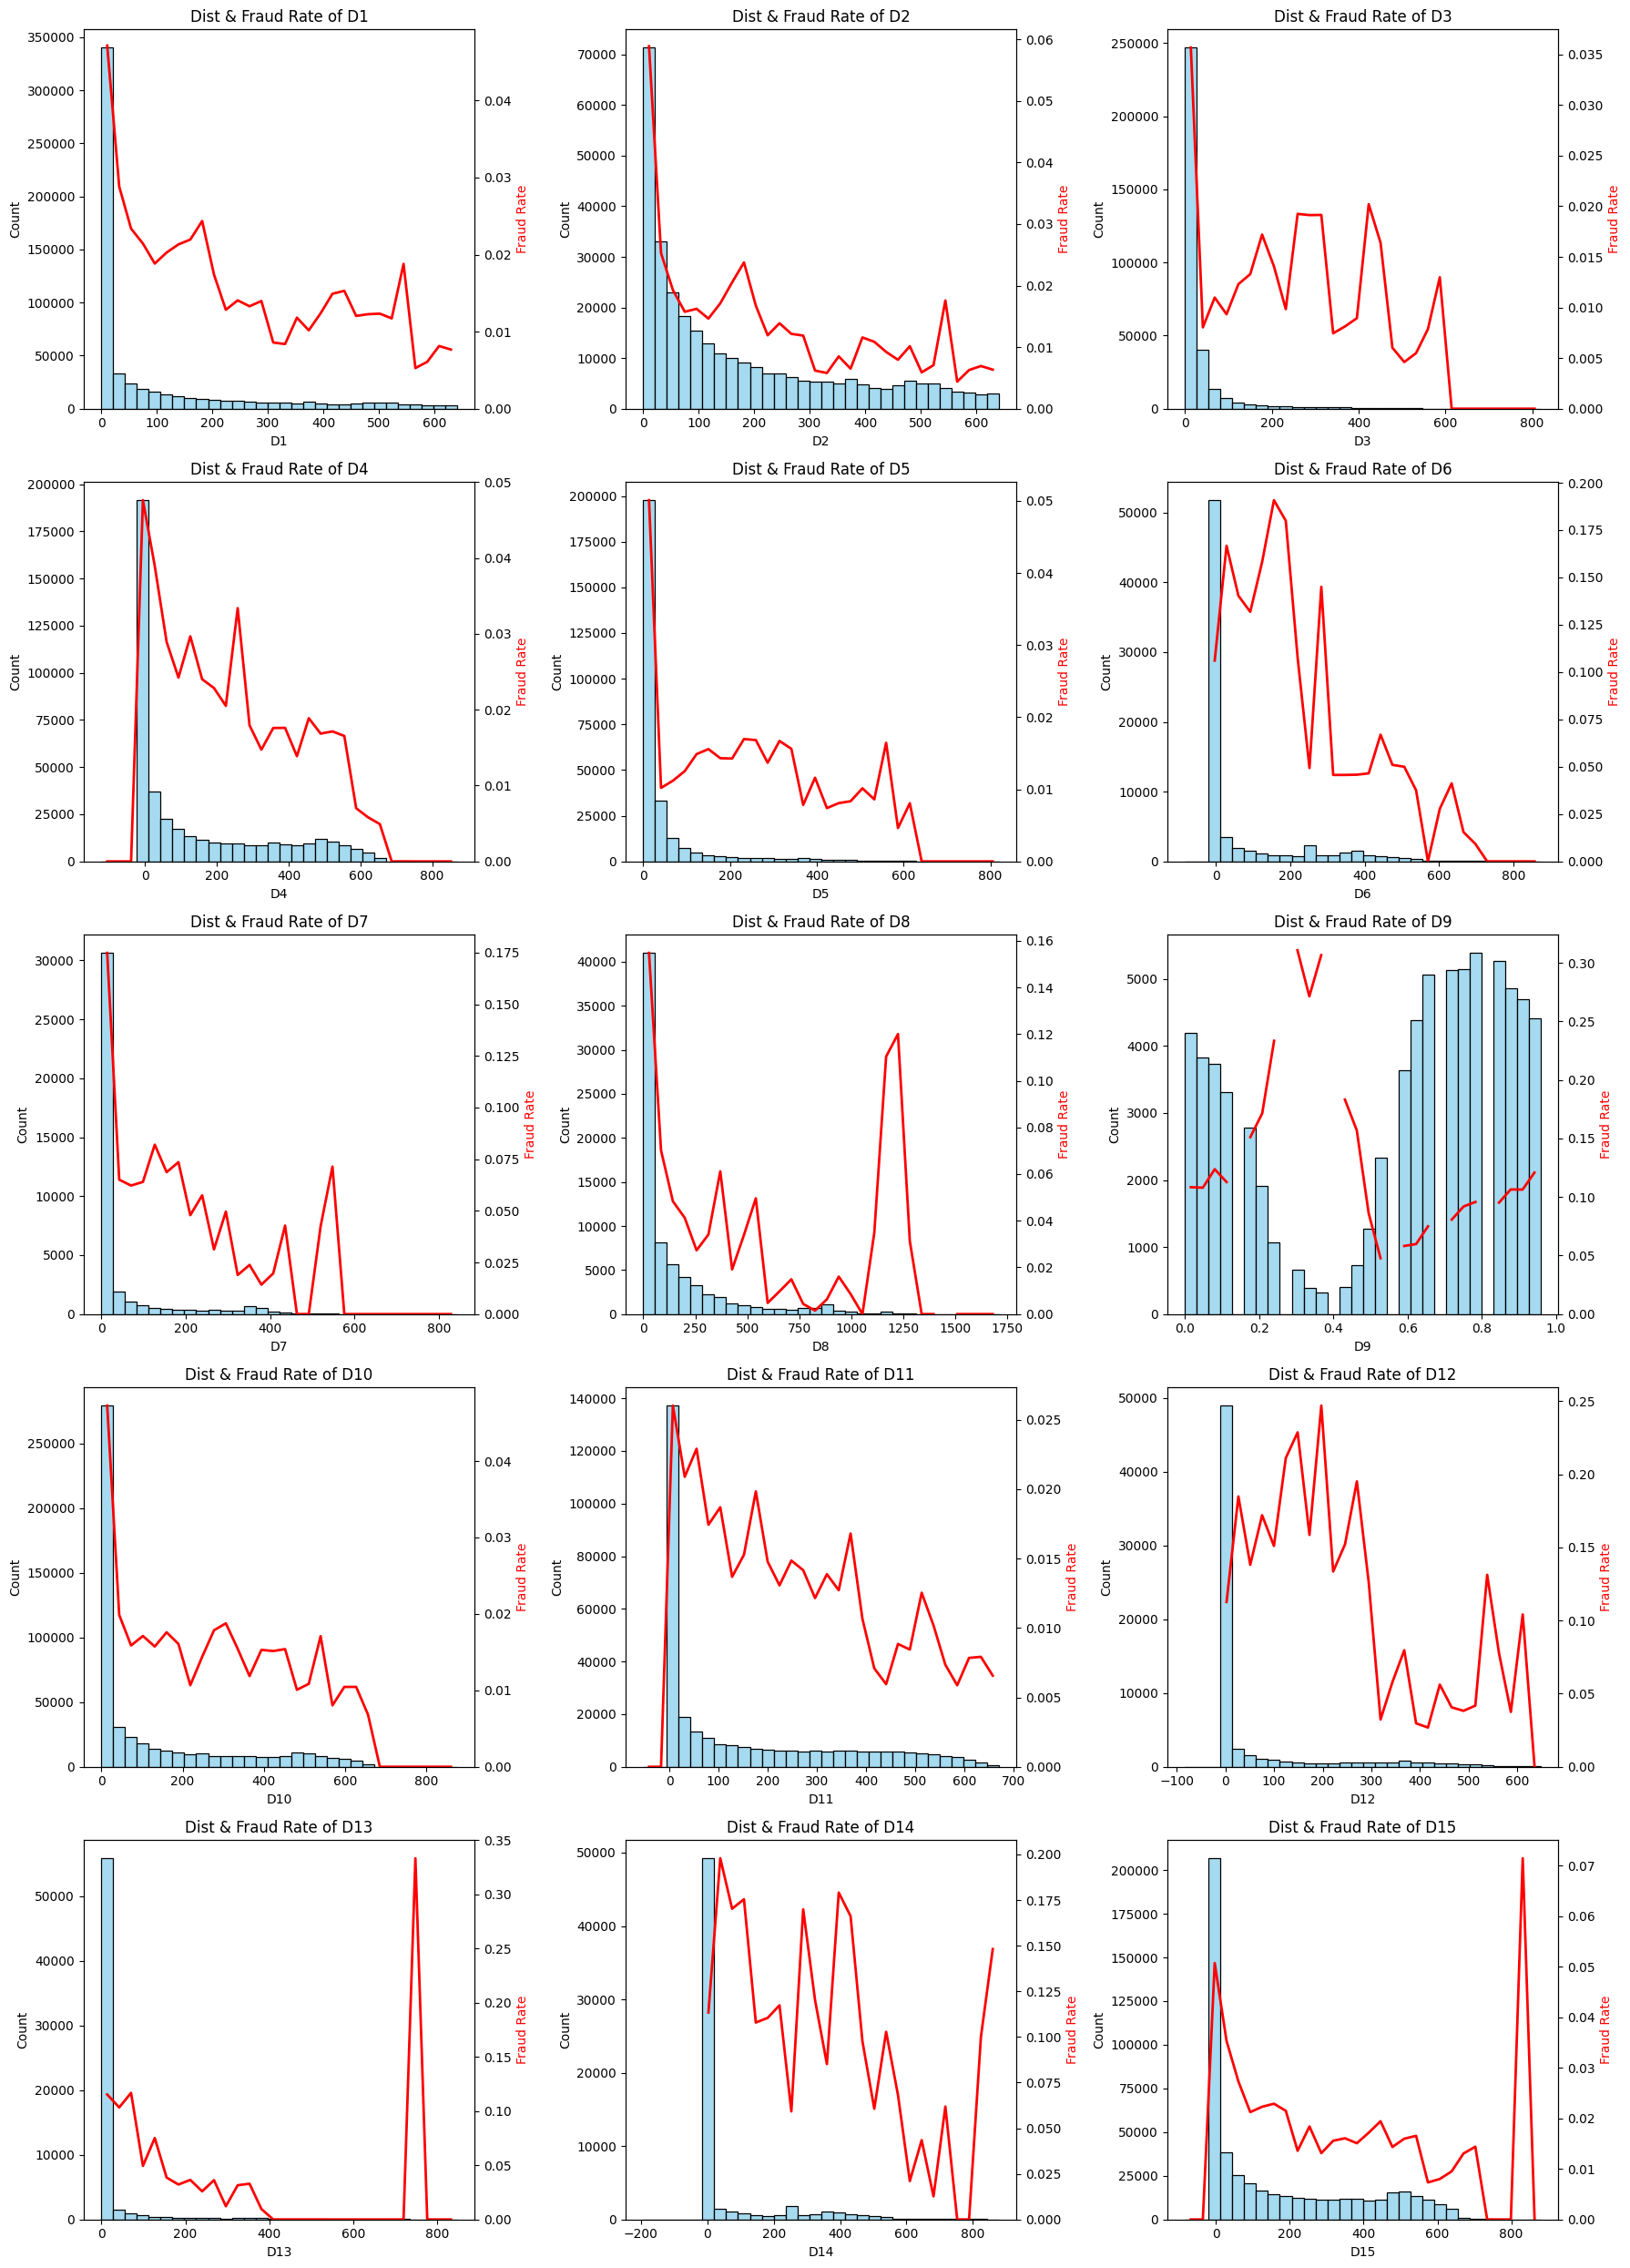


 Correlation Matrix


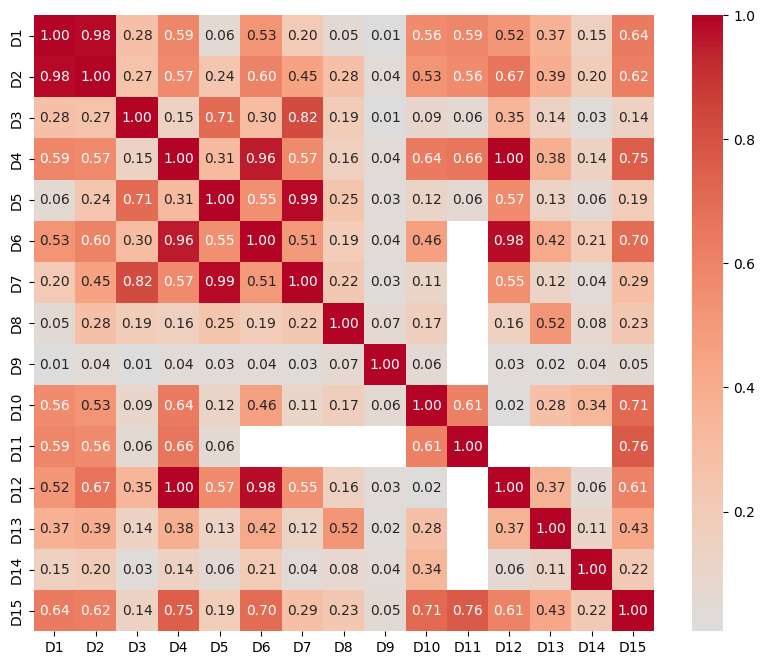

In [10]:
cols = [c for c in d_cols if c in train.columns]
get_descriptive_stats(train, cols)
plot_group_analysis(train, 'D1-D15', cols)

# V Feature, ref: https://www.kaggle.com/code/cdeotte/eda-for-columns-v-and-id/notebook#NAN-search

In [11]:
v_cols = [f'V{i}' for i in range(1, 340)]

nan_groups = {}
for col in v_cols:
    if col in train.columns:
        nan_count = train[col].isnull().sum()
        if nan_count not in nan_groups:
            nan_groups[nan_count] = []
        nan_groups[nan_count].append(col)

for count, cols in nan_groups.items():
    print(f"Nhóm có {count} NaN gồm {len(cols)} biến: {cols}")

Nhóm có 279287 NaN gồm 11 biến: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11']
Nhóm có 76073 NaN gồm 23 biến: ['V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34']
Nhóm có 168969 NaN gồm 18 biến: ['V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52']
Nhóm có 77096 NaN gồm 22 biến: ['V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74']
Nhóm có 89164 NaN gồm 20 biến: ['V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94']
Nhóm có 314 NaN gồm 43 biến: ['V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V11

In [12]:
import pandas as pd
import numpy as np

def filter_v_cols_by_nunique(df, v_blocks, threshold=0.9):
    unique_counts = df[v_blocks].nunique().sort_values(ascending=False)
    sorted_cols = unique_counts.index.tolist()

    corr_matrix = df[v_blocks].corr().abs()

    cols_drop = set()
    cols_keep = []

    for col in sorted_cols:
        if col in cols_drop:
            continue

        cols_keep.append(col)

        highly_correlated = corr_matrix.index[corr_matrix[col] > threshold].tolist()
        for corr_col in highly_correlated:
            if corr_col != col:
                cols_drop.add(corr_col)

    return cols_keep, list(cols_drop)

In [13]:
v_keep = []
v_drop = []

for nan_count, block_cols in nan_groups.items():

    if len(block_cols) > 1:
        keep, drop = filter_v_cols_by_nunique(train, block_cols, threshold=0.9)
        v_keep.extend(keep)
        v_drop.extend(drop)
    else:
        v_keep.extend(block_cols)

print("=========================================")
print(f"Tổng số biến V ban đầu: {len(v_keep) + len(v_drop)}")
print(f"Tổng số biến V được giữ lại: {len(v_keep)}")
print(v_keep)

Tổng số biến V ban đầu: 339
Tổng số biến V được giữ lại: 206
['V3', 'V6', 'V7', 'V9', 'V2', 'V8', 'V4', 'V11', 'V1', 'V18', 'V16', 'V20', 'V23', 'V24', 'V26', 'V30', 'V13', 'V25', 'V27', 'V14', 'V38', 'V37', 'V44', 'V40', 'V52', 'V47', 'V43', 'V46', 'V50', 'V36', 'V49', 'V41', 'V56', 'V55', 'V60', 'V58', 'V62', 'V67', 'V74', 'V66', 'V63', 'V54', 'V70', 'V61', 'V68', 'V65', 'V78', 'V77', 'V87', 'V86', 'V81', 'V85', 'V92', 'V82', 'V83', 'V79', 'V76', 'V91', 'V89', 'V88', 'V127', 'V130', 'V136', 'V131', 'V135', 'V129', 'V99', 'V106', 'V100', 'V123', 'V124', 'V125', 'V98', 'V111', 'V112', 'V108', 'V109', 'V110', 'V114', 'V116', 'V115', 'V121', 'V117', 'V120', 'V119', 'V118', 'V122', 'V107', 'V162', 'V161', 'V139', 'V147', 'V158', 'V155', 'V138', 'V142', 'V141', 'V160', 'V159', 'V165', 'V164', 'V166', 'V152', 'V203', 'V202', 'V207', 'V215', 'V216', 'V205', 'V206', 'V187', 'V176', 'V199', 'V183', 'V186', 'V172', 'V191', 'V173', 'V209', 'V210', 'V208', 'V180', 'V171', 'V201', 'V170', 'V185', 

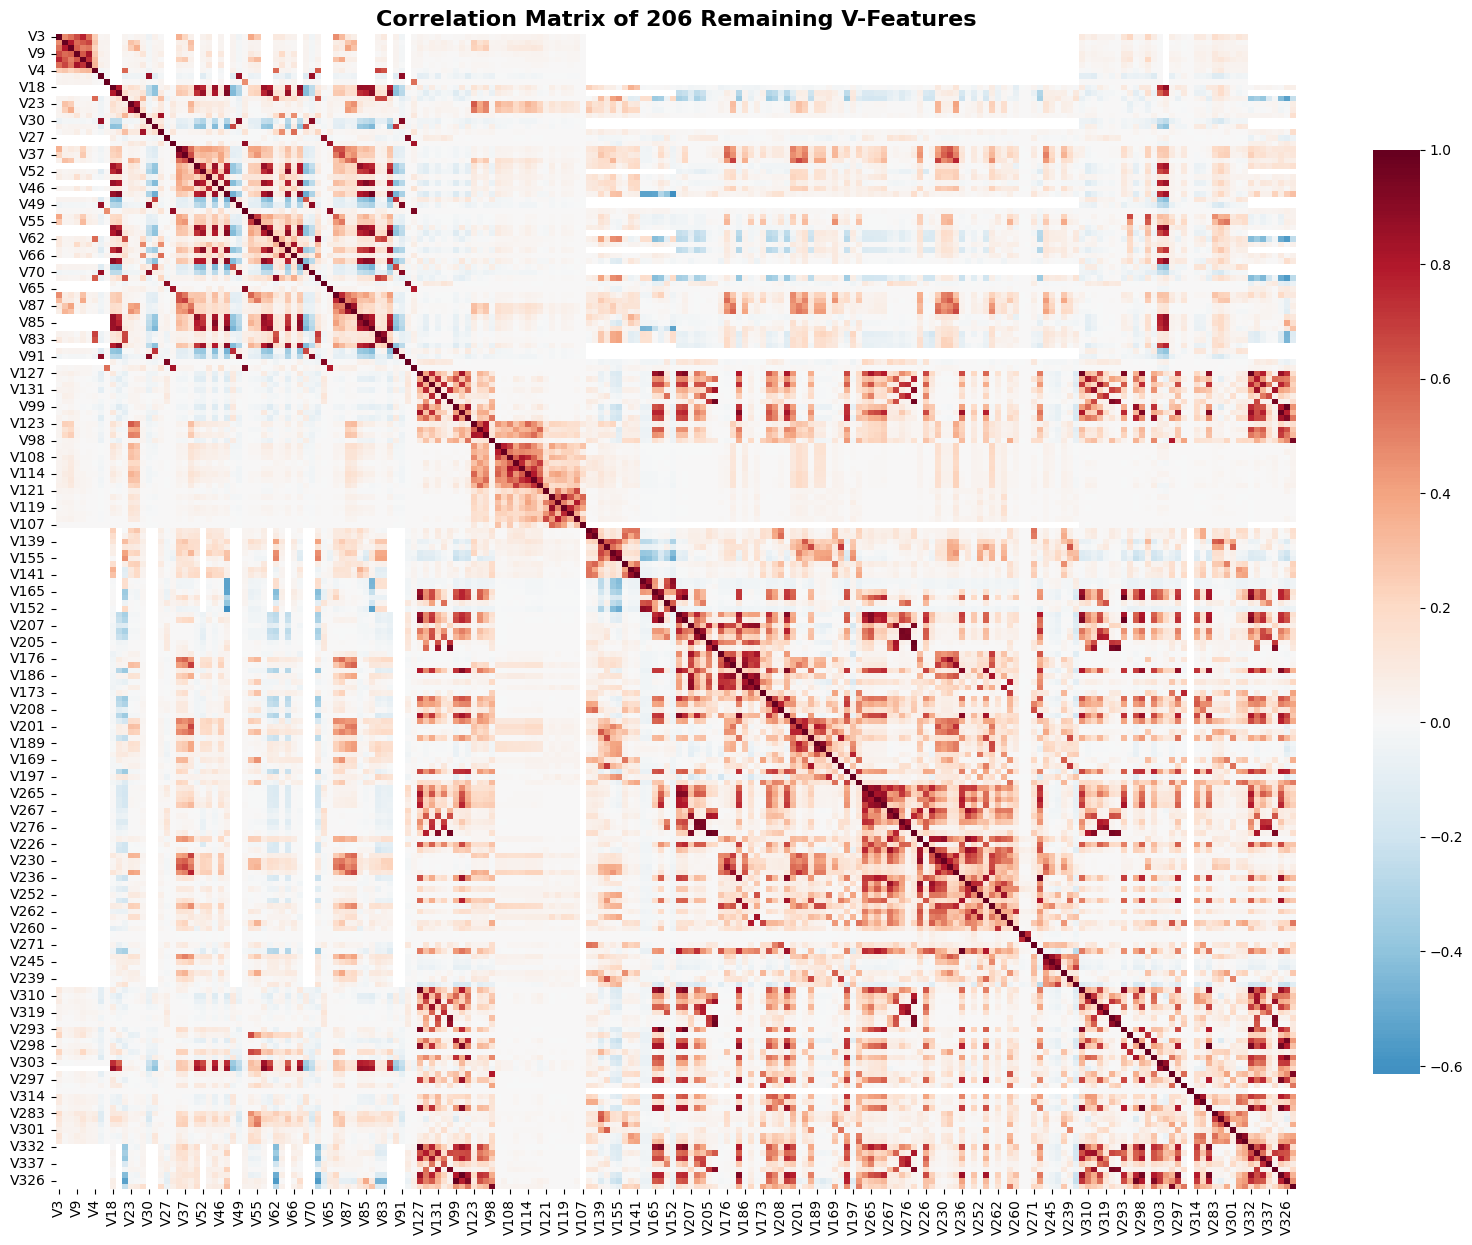

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

v_cols_remaining = [col for col in v_keep if col.startswith('V')]

corr_remaining = train[v_cols_remaining].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_remaining,
            cmap='RdBu_r',
            center=0,
            annot=False,
            cbar_kws={"shrink": .8})

plt.title(f"Correlation Matrix of {len(v_cols_remaining)} Remaining V-Features", fontsize=16, fontweight='bold')
plt.show()

# Một số biến V còn lại vẫn còn tương quan khá cao, ta xây dựng mô hình và tính feature importance để quyết định giữ lại V nào

In [15]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

v_cols = v_keep

X = train[v_cols]
y = train['isFraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[487]	training's auc: 0.925444	valid_1's auc: 0.890982


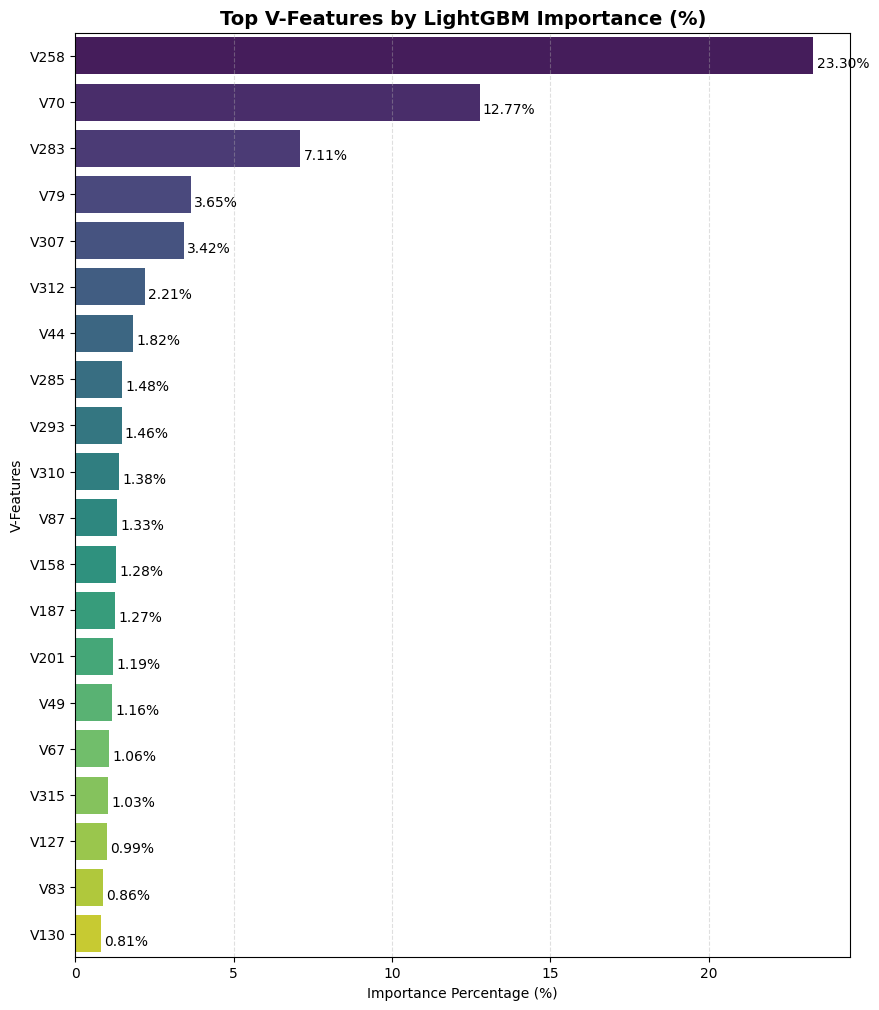

In [16]:
n_neg = train['isFraud'].value_counts()[0]
n_pos = train['isFraud'].value_counts()[1]

scale_pos_weight = n_neg / n_pos

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42
}

model = lgb.train(
    params,
    dtrain,
    num_boost_round=500,
    valid_sets=[dtrain, dval],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)


importance_df = pd.DataFrame({
    'feature': v_cols,
    'importance': model.feature_importance(importance_type='gain') # Dùng 'gain' để đo đóng góp vào độ chính xác
}).sort_values(by='importance', ascending=False)


total_gain = importance_df['importance'].sum()

importance_df['importance_pct'] = (importance_df['importance'] / total_gain) * 100

importance_df['cumulative_pct'] = importance_df['importance_pct'].cumsum()

plt.figure(figsize=(10, 12))
sns.barplot(x='importance_pct', y='feature', data=importance_df.head(20), palette='viridis')

for i, v in enumerate(importance_df['importance_pct'].head(20)):
    plt.text(v + 0.1, i + .25, f'{v:.2f}%', color='black', fontsize=10)

plt.title('Top V-Features by LightGBM Importance (%)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Percentage (%)')
plt.ylabel('V-Features')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

In [17]:
v_cols_keep = importance_df[importance_df['cumulative_pct'] <= 99.9]['feature'].tolist()
v_cols_drop = [c for c in v_cols if c not in v_cols_keep]

print(f"Số biến V cần thiết để giữ lại 99.9% thông tin: {len(v_cols_keep)}")
print(v_cols_keep)

Số biến V cần thiết để giữ lại 99.9% thông tin: 175
